# 05 — Positional Encoding: Attention'a Kelime Sırasını Öğretmek

**Önkoşul:** `03_self_attention` ve `04_multi_head_attention`. 04'ün Egzersiz 6'sında şunu gördük: cümlenin kelimelerini karıştırıp multi-head attention'a verince, her kelimenin çıktısı **aynı** kalıyor, sadece yeri değişiyor. Yani attention kelime sırasını hiç görmüyor.

### Bu notebook'un 3 ana fikri

1. **Sorun:** Attention bir cümleyi kelime **torbası** gibi görüyor. `"büyük ev"` (bir ev) ile `"ev büyük"` (bir yargı) onun için aynı şey.
2. **Çözüm fikri:** Her kelimenin embedding'ine, **bulunduğu yeri anlatan** 50 sayılık bir "konum vektörü" ekle. Kelime + konum = attention'ın yeni girdisi.
3. **Hangi konum vektörü?** Farklı hızlarda dönen **saat ibreleri**. Hızlı ibreler yan yana kelimeleri, yavaş ibreler uzak kelimeleri ayırt ediyor. Sayılar hep -1 ile 1 arasında kalıyor, her konumun deseni benzersiz, ve iki konumun benzerliği sadece **aralarındaki mesafeye** bağlı.

Sonda modern modellerin kullandığı **RoPE**'a kısa bir bakış var: aynı saat fikri, ama toplamak yerine döndürerek.

Her bölümde önce **sezgi**, sonra **kod**, sonra **"Ne gördük?"** geliyor. "(İsteğe bağlı)" kısımları ilk okumada atlayabilirsin.

**Kullanılan veri:** `../02_embeddings/data/corpus_turkce.txt`, 02-04'teki aynı Türkçe Wikipedia cümleleri (*Turkish-Wiki-NER-Dataset*, CC-BY-SA-4.0).

**Reprodüksiyon notu:** 04'teki gibi her bölüm kendi üretecini (`rng_toy`, `rng_emb`, `rng_real`, `rng_rope`) kendisi oluşturuyor. Global isimler: `E_tr`, `word2id_tr`, `d_model` (= 50), `PE`. Egzersizlerde bunları ezme.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, time
from collections import Counter

def softmax(x, axis=-1):
    """03 ile aynı: sayıları toplamı 1 olan ağırlıklara çevirir."""
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def scaled_dot_product_attention(X, W_Q, W_K, W_V, mask=None):
    """03'teki fonksiyonun aynısı: TEK bir attention kafası."""
    Q, K, V = X @ W_Q, X @ W_K, X @ W_V
    scores = (Q @ K.T) / np.sqrt(K.shape[-1])
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

def split_heads(M, h):
    """04 ile aynı: (n, 50) -> (h, n, 50/h)"""
    n, hd = M.shape
    return M.reshape(n, h, hd // h).transpose(1, 0, 2)

def merge_heads(M):
    """04 ile aynı: (h, n, d_k) -> (n, h*d_k)"""
    h, n, d_k = M.shape
    return M.transpose(1, 0, 2).reshape(n, h * d_k)

def multi_head_attention(X, W_Q, W_K, W_V, W_O, h, mask=None):
    """04'teki hızlı (döngüsüz) sürümün aynısı."""
    Q, K, V = split_heads(X @ W_Q, h), split_heads(X @ W_K, h), split_heads(X @ W_V, h)
    scores = Q @ K.transpose(0, 2, 1) / np.sqrt(Q.shape[-1])
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    return merge_heads(weights @ V) @ W_O, weights

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

### Hazırlık: Türkçe embedding'leri eğit

Gerçek kelimelerle çalışabilmek için 04'teki hücrenin **aynısını** çalıştırıyoruz (aynı veri, aynı kod, aynı tohum → aynı `E_tr`). Yaklaşık 15-60 saniye sürer.

In [2]:
def tokenize_tr(text):
    """02 ve 04'teki tokenize_tr ile aynı"""
    text = text.replace("İ", "i").replace("I", "ı").lower()
    return re.findall(r"[a-zçğıöşü]+(?:'[a-zçğıöşü]+)?", text)

def build_vocab(tokens, min_count=5, max_vocab=4000):
    """02'deki build_vocab ile aynı"""
    c = Counter(tokens)
    items = sorted(((w, f) for w, f in c.items() if f >= min_count), key=lambda x: -x[1])
    items = items[:max_vocab]
    word2id = {w: i for i, (w, f) in enumerate(items)}
    id2word = [w for w, f in items]
    freqs = np.array([f for w, f in items], dtype=np.float64)
    return word2id, id2word, freqs

def make_neg_table(freqs, rng, size=2_000_000, power=0.75):
    p = freqs ** power
    p = p / p.sum()
    counts = np.round(p * size).astype(np.int64)
    table = np.repeat(np.arange(len(freqs)), np.maximum(counts, 1))
    rng.shuffle(table)
    return table

def make_pairs(tokens, word2id, rng, window=4, subsample_t=1e-3):
    ids = np.array([word2id[w] for w in tokens if w in word2id], dtype=np.int64)
    total = len(ids)
    freq_all = Counter(ids.tolist())
    keep_prob = {}
    for wid, f in freq_all.items():
        fr = f / total
        p = (np.sqrt(fr/subsample_t) + 1) * (subsample_t/fr)
        keep_prob[wid] = min(p, 1.0)
    mask = np.array([rng.random() < keep_prob[w] for w in ids])
    ids = ids[mask]
    centers, contexts = [], []
    n = len(ids)
    for i in range(n):
        w = rng.integers(1, window+1)
        for j in range(max(0, i-w), min(n, i+w+1)):
            if j != i:
                centers.append(ids[i]); contexts.append(ids[j])
    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def train_sgns(centers, contexts, vocab_size, rng, dim=50, epochs=8, batch_size=1024,
               lr=0.03, k_neg=5, neg_table=None, verbose=True):
    W_in = (rng.random((vocab_size, dim)) - 0.5) / dim
    W_out = np.zeros((vocab_size, dim))
    n = len(centers)
    for ep in range(epochs):
        perm = rng.permutation(n)
        ep_loss, seen = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            c, o = centers[idx], contexts[idx]
            bs = len(c)
            neg = neg_table[rng.integers(0, len(neg_table), size=(bs, k_neg))]
            vc, vo, vneg = W_in[c], W_out[o], W_out[neg]
            pos_dot = np.sum(vc*vo, axis=1)
            neg_dot = np.einsum('bd,bkd->bk', vc, vneg)
            sig_pos, sig_neg = sigmoid(pos_dot), sigmoid(neg_dot)
            loss = -(np.log(sig_pos+1e-10).sum() + np.log(1-sig_neg+1e-10).sum())
            ep_loss += loss; seen += bs
            grad_pos = (sig_pos - 1.0)[:, None]
            d_vc = grad_pos*vo + np.einsum('bk,bkd->bd', sig_neg, vneg)
            d_vo = grad_pos*vc
            d_vneg = sig_neg[:, :, None]*vc[:, None, :]
            np.add.at(W_in, c, -lr*d_vc)
            np.add.at(W_out, o, -lr*d_vo)
            np.add.at(W_out, neg, -lr*d_vneg)
        if verbose:
            print(f"  epoch {ep+1}/{epochs}  ortalama kayıp/çift = {ep_loss/seen:.4f}")
    return W_in, W_out

def nearest(word, E, word2id, id2word, topn=8):
    v = E[word2id[word]]
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ (v / (np.linalg.norm(v) + 1e-9))
    return [(id2word[i], round(float(sims[i]), 3)) for i in np.argsort(-sims) if id2word[i] != word][:topn]

rng_emb = np.random.default_rng(42)          # sadece bu hücreye ait üreteç
corpus_tr = open("../02_embeddings/data/corpus_turkce.txt", encoding="utf-8").read()
tokens_tr = tokenize_tr(corpus_tr)
word2id_tr, id2word_tr, freqs_tr = build_vocab(tokens_tr, min_count=5, max_vocab=4000)
centers_tr, contexts_tr = make_pairs(tokens_tr, word2id_tr, rng_emb, window=4)
neg_table_tr = make_neg_table(freqs_tr, rng_emb)
print(f"Türkçe sözlük boyutu: {len(word2id_tr)}   eğitim çifti: {len(centers_tr):,}")

t0 = time.time()
W_in_tr, W_out_tr = train_sgns(centers_tr, contexts_tr, len(word2id_tr), rng_emb,
                               dim=50, epochs=8, neg_table=neg_table_tr)
print(f"Eğitim süresi: {time.time()-t0:.1f} sn")
E_tr = W_in_tr + W_out_tr
print("\n'kara'nın en yakın komşuları:", nearest("kara", E_tr, word2id_tr, id2word_tr))

Türkçe sözlük boyutu: 4000   eğitim çifti: 664,938


  epoch 1/8  ortalama kayıp/çift = 3.1298


  epoch 2/8  ortalama kayıp/çift = 2.6569


  epoch 3/8  ortalama kayıp/çift = 2.5760


  epoch 4/8  ortalama kayıp/çift = 2.4992


  epoch 5/8  ortalama kayıp/çift = 2.4338


  epoch 6/8  ortalama kayıp/çift = 2.3798


  epoch 7/8  ortalama kayıp/çift = 2.3359


  epoch 8/8  ortalama kayıp/çift = 2.3001
Eğitim süresi: 11.7 sn

'kara'nın en yakın komşuları: [('kuvvetleri', 0.693), ('yoluyla', 0.628), ('komutanlığı', 0.552), ('üstüne', 0.502), ('savunma', 0.477), ("ingiltere'ye", 0.453), ('dönemin', 0.453), ('isteyen', 0.451)]


## 1) Sorun: attention kelime sırasını görmüyor

### Sezgi

Türkçe'de şu iki ifadeye bak:

- `"büyük ev"` → bir şeyin adı (*the big house*)
- `"ev büyük"` → bir yargı (*the house is big*)

Aynı iki kelime, farklı sıra, farklı anlam. Türkçe ekler sayesinde sırası görece serbest bir dil (`"Ali kitabı okudu"` ile `"kitabı Ali okudu"` aynı olayı anlatıyor), ama sıra yine de anlam taşıyor.

Attention ise cümleye **karıştırılmış bir deste kart** gibi bakıyor. 03'ü hatırla: `"kara"`nın `"kutu"`ya ne kadar dikkat edeceği, sadece bu iki kelimenin **vektörlerinden** hesaplanıyor. Vektörlerin içinde "ben kaçıncı sıradayım" diye bir bilgi yok. Kelimelerin yerini değiştirmek, dikkat tablosunun sadece satırlarını ve sütunlarını karıştırıyor. İçindeki sayılar aynı.

Küçük bir deneyle görelim: 3 kelime, rastgele 8 sayılık vektörler, iki farklı sıra.

In [3]:
rng_toy = np.random.default_rng(0)
words_toy = ["kara", "kutu", "düştü"]
emb_toy = {w: rng_toy.normal(size=8) for w in words_toy}               # her kelimeye rastgele 8 sayı
W_Q_toy, W_K_toy, W_V_toy = (rng_toy.normal(size=(8, 8)) / np.sqrt(8) for _ in range(3))

def run_toy(order, pos_vectors=None):
    """Kelimeleri verilen sırayla attention'a sok. Dönüş: {kelime: çıktı vektörü}"""
    X = np.stack([emb_toy[w] for w in order])
    if pos_vectors is not None:          # Bölüm 6'da kullanacağız: konum vektörü ekle
        X = X + pos_vectors[:len(order)]
    out, _ = scaled_dot_product_attention(X, W_Q_toy, W_K_toy, W_V_toy)
    return dict(zip(order, out))

sira_1 = ["kara", "kutu", "düştü"]
sira_2 = ["düştü", "kara", "kutu"]
o1, o2 = run_toy(sira_1), run_toy(sira_2)
print(f"Sıra 1: {' '.join(sira_1)}      Sıra 2: {' '.join(sira_2)}\n")
print(f"{'kelime':>7} | {'sıra 1 çıktısı (ilk 4 sayı)':>34} | {'sıra 2 çıktısı (ilk 4 sayı)':>34} | aynı mı?")
for w in words_toy:
    print(f"{w:>7} | {str(np.round(o1[w][:4], 3)):>34} | {str(np.round(o2[w][:4], 3)):>34} | {np.allclose(o1[w], o2[w])}")

Sıra 1: kara kutu düştü      Sıra 2: düştü kara kutu

 kelime |        sıra 1 çıktısı (ilk 4 sayı) |        sıra 2 çıktısı (ilk 4 sayı) | aynı mı?
   kara |      [ 0.336  0.327  0.249 -0.008] |      [ 0.336  0.327  0.249 -0.008] | True
   kutu |      [ 0.262  0.165  0.28  -0.164] |      [ 0.262  0.165  0.28  -0.164] | True
  düştü |      [ 0.268 -0.046  0.549 -0.704] |      [ 0.268 -0.046  0.549 -0.704] | True


**Ne gördük?** Her kelimenin çıktısı iki sırada da **birebir aynı**. `"kara"` ister başta ister ortada dursun, attention ona aynı yeni temsili veriyor. Model için `"kara kutu düştü"` ile `"düştü kara kutu"` arasında fark yok.

**Neden?** Attention'ın her adımı (Q, K, V hesaplamak, benzerlik, softmax, ağırlıklı toplam) ya **tek bir kelimeye** uygulanıyor ya da **kelime çiftlerine**. Hiçbir adım "kaçıncı sıradasın?" diye sormuyor. Bu yüzden sıra bilgisini **dışarıdan, girdinin içine koymamız** gerekiyor.

## 2) Çözüm fikri: kelimeye bir "konum kartı" iliştir

Her kelimenin 50 sayılık embedding'ine, bulunduğu konumu anlatan 50 sayılık bir vektör **ekleyeceğiz**:

> **girdi = embedding (kelime ne?) + konum vektörü (kelime nerede?)**

Böylece `"ev"` 1. sırada ve 2. sırada farklı bir vektör olacak, attention da farkı görebilecek. Asıl soru: **konum vektörü nasıl bir şey olmalı?** Önce akla ilk gelen iki fikri deneyelim, neden bozulduklarını görelim.

### Fikir A: sıra numarasını doğrudan ekle

En basiti: 0. kelimenin her sayısına 0, 1. kelimeye 1, 100. kelimeye 100 ekle. Sorun: embedding'deki sayılar küçük (ortalama mutlak değer ~0.45). Konum büyüdükçe bu küçük sayılar, eklenen büyük sayının yanında **kayboluyor**. İki alakasız kelimenin (`"kara"` ve `"okudu"`) konum eklendikten sonra birbirine ne kadar benzediğine bakalım:

In [4]:
v_kara, v_okudu = E_tr[word2id_tr["kara"]], E_tr[word2id_tr["okudu"]]
print(f"embedding'deki sayıların ortalama büyüklüğü: {np.abs(E_tr).mean():.2f}\n")
print(f"{'konum':>6} | {'benzerlik(kara, okudu)':>23}")
for pos in [0, 1, 5, 20, 100, 500]:
    print(f"{pos:>6} | {cosine(v_kara + pos, v_okudu + pos):>23.4f}")

embedding'deki sayıların ortalama büyüklüğü: 0.45

 konum |  benzerlik(kara, okudu)
     0 |                 -0.0203
     1 |                  0.7970
     5 |                  0.9903
    20 |                  0.9994
   100 |                  1.0000
   500 |                  1.0000


**Ne gördük?** Konum 0'da iki kelime birbirine benzemiyor. Konum 20'de benzerlik 1'e yaklaşmış, 500'de neredeyse 1. Yani uzun bir metnin sonlarında **her kelime birbirine benziyor**: konum sinyali, kelimenin kendisini boğuyor.

### Fikir B: sıra numarasını 0-1 arasına sıkıştır

"O zaman konumu cümle uzunluğuna bölelim, hep 0 ile 1 arasında kalsın" diyebiliriz. Bu da başka bir sorun çıkarıyor:

| | 5 kelimelik cümle | 101 kelimelik cümle |
|---|---|---|
| 0.5 değeri | 3. kelime | 51. kelime |
| iki komşu kelime arası fark | 0.25 | 0.01 |

Aynı sayı, cümle uzunluğuna göre farklı bir konum demek. "Yan yana olmak" da her cümlede farklı bir farka karşılık geliyor. Model "yanımdaki kelime" kavramını öğrenemez.

### İstediğimiz 4 özellik

1. **Sayılar küçük ve sınırlı kalmalı** (Fikir A'nın sorunu) → kelimeyi boğmasın.
2. **Her konumun deseni farklı olmalı** → iki konum karışmasın.
3. **Cümle uzunluğundan bağımsız olmalı** (Fikir B'nin sorunu) → 3. kelime her cümlede aynı vektörü alsın.
4. **"3 adım ötede" her yerde aynı anlama gelmeli** → 5. ile 8. kelime arasındaki ilişki, 50. ile 53. arasındakiyle aynı görünsün.

## 3) Saat ibreleri: sinüs ve kosinüs

### Sezgi

Bir saate bak: saniye, dakika ve saat ibreleri var. Her biri farklı hızda dönüyor.

- **Saniye ibresi** tek başına yetmez: 0. saniye ile 60. saniye aynı görünür (ibre başa döndü).
- Ama **dakika ibresiyle birlikte** bakınca ayırt edebilirsin. Hızlı ibre yakın anları, yavaş ibre uzak anları ayırt ediyor.
- İbrenin ucu her zaman aynı çemberin üstünde. Ne kadar zaman geçerse geçsin **sayılar büyümüyor** (özellik 1).

Positional encoding tam olarak bu: 50 sayılık konum vektörü = **25 tane ibre**, her biri farklı hızda dönüyor. Kelimenin konumu = geçen "zaman". Bir ibrenin durumunu 2 sayıyla yazıyoruz: ucunun yatay ve dikey koordinatı, yani **sin(açı)** ve **cos(açı)**.

İbre `i`'nin her adımda döndüğü açı (radyan):

$$\omega_i = \frac{1}{10000^{\,2i/d}} \qquad \text{konum } pos\text{'taki açı} = pos \cdot \omega_i$$

- İbre 0: $\omega_0 = 1$ radyan/adım (~57°), **en hızlı**.
- Son ibre: $\omega_{24} \approx 0.00014$ radyan/adım, **çok yavaş**. Tam bir tur için ~44.000 adım gerekiyor.

Konum vektörü de bu açıların sinüs ve kosinüsleri sırayla dizilerek oluşuyor: `[sin(pos·ω₀), cos(pos·ω₀), sin(pos·ω₁), cos(pos·ω₁), ...]`. Orijinal makaledeki formül (Vaswani ve ark., 2017) budur. Formülü ezberlemen gerekmiyor: **"i. sayı çifti = i. ibre"** fikri yeterli.

Önce ibreleri gözümüzle görelim:

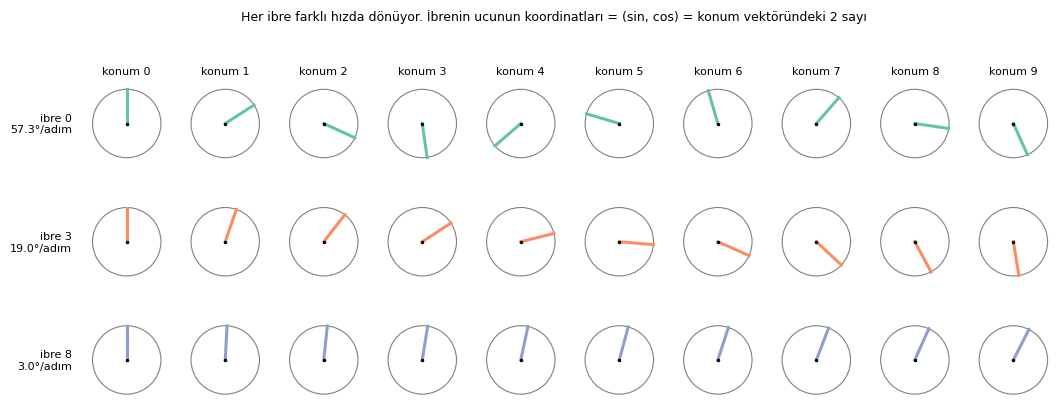

In [5]:
def omegas(d, base=10000):
    """Her ibrenin adım başına dönüş açısı (radyan). d sayı -> d/2 ibre."""
    return 1.0 / base ** (np.arange(0, d, 2) / d)

d_model = 50
w_ = omegas(d_model)
secilen = [0, 3, 8]                # hızlı, orta, yavaş üç ibre
n_show = 10
fig, axes = plt.subplots(len(secilen), n_show, figsize=(1.25 * n_show, 1.45 * len(secilen)))
for r, i in enumerate(secilen):
    for pos in range(n_show):
        ax = axes[r, pos]
        a = pos * w_[i]
        ax.add_patch(plt.Circle((0, 0), 1, fill=False, lw=0.8, color="gray"))
        ax.plot([0, np.sin(a)], [0, np.cos(a)], lw=2.2, color=plt.cm.Set2(r))   # uç = (sin, cos)
        ax.plot(0, 0, "k.", ms=3)
        ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect("equal"); ax.axis("off")
        if r == 0:
            ax.set_title(f"konum {pos}", fontsize=8)
    axes[r, 0].text(-1.6, 0, f"ibre {i}\n{np.degrees(w_[i]):.1f}°/adım", ha="right", va="center", fontsize=8)
plt.suptitle("Her ibre farklı hızda dönüyor. İbrenin ucunun koordinatları = (sin, cos) = konum vektöründeki 2 sayı",
             fontsize=9, y=1.03)
plt.savefig("pe_clocks.png", dpi=130, bbox_inches="tight")
plt.show()

**Ne gördük?** İbre 0 her adımda büyük bir sıçrama yapıyor: yan yana iki kelimeyi kolayca ayırt eder, ama 6-7 adımda neredeyse başa dönüyor. İbre 8 zar zor kıpırdıyor: komşuları ayırt etmekte zayıf, ama uzak konumları ayırt etmeye yarıyor. **Hepsine birlikte bakınca** her konumun kendine özgü bir "saat görüntüsü" var.

Şimdi bunu fonksiyona çevirip 100 konum × 50 sayının tamamına bakalım:

PE şekli: (2000, 50)   <- 2000 konum x 50 sayı


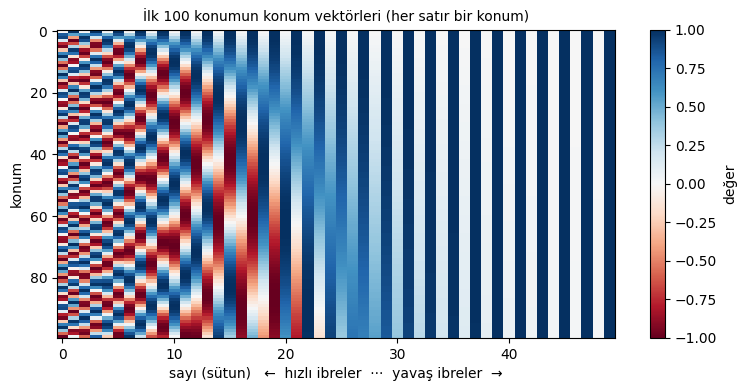

In [6]:
def positional_encoding(n_pos, d, base=10000):
    """Sinüzoidal konum vektörleri. Dönüş: (n_pos, d). Satır pos = konum pos'un 50 sayısı.
    Çift sütunlar (0, 2, 4, ...) = sin, tek sütunlar (1, 3, 5, ...) = cos. Sütun çifti i = ibre i."""
    pos = np.arange(n_pos)[:, None]                 # (n_pos, 1)
    angles = pos * omegas(d, base)[None, :]         # (n_pos, d/2): her konum x her ibre için açı
    PE = np.zeros((n_pos, d))
    PE[:, 0::2] = np.sin(angles)
    PE[:, 1::2] = np.cos(angles)
    return PE

PE = positional_encoding(2000, d_model)             # ilk 2000 konum, global olarak kullanacağız
print("PE şekli:", PE.shape, "  <- 2000 konum x 50 sayı")

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(PE[:100], cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax.set_xlabel("sayı (sütun)   ←  hızlı ibreler  ···  yavaş ibreler  →"); ax.set_ylabel("konum")
ax.set_title("İlk 100 konumun konum vektörleri (her satır bir konum)", fontsize=10)
plt.colorbar(im, ax=ax, label="değer")
plt.savefig("pe_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

**Ne gördük?**

- **Soldaki sütunlar** (hızlı ibreler) her satırda renk değiştiriyor: kırmızı-mavi çizgiler sık.
- **Sağa gittikçe** değişim yavaşlıyor. En sağdaki sütunlar 100 konum boyunca neredeyse hiç değişmiyor (sin ≈ 0 → beyaz, cos ≈ 1 → mavi).
- Her satır farklı bir renk deseni: konumun **parmak izi**. Ve bu desen cümle uzunluğuna bağlı değil: 3. konumun satırı her cümlede aynı (özellik 3).

### Parçaları birleştirelim: akış şeması

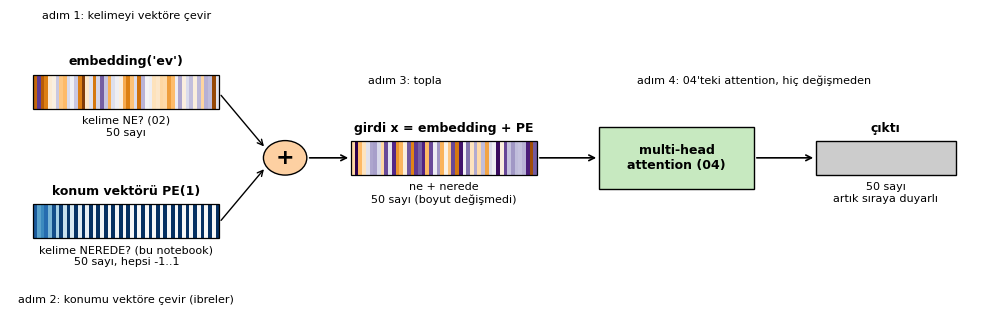

In [7]:
def draw_pipeline(save="positional_pipeline.png"):
    fig, ax = plt.subplots(figsize=(12.5, 4.0))
    ax.set_xlim(0, 12.5); ax.set_ylim(-0.6, 4.4); ax.axis("off")

    def stripes(x, y, w, hgt, values, cmap, label, sub):
        """Vektörü ince renkli şeritler olarak çiz: her şerit bir sayı."""
        vals = np.asarray(values)
        norm = plt.Normalize(-np.abs(vals).max(), np.abs(vals).max())
        for k, v in enumerate(vals):
            ax.add_patch(plt.Rectangle((x + k * w / len(vals), y), w / len(vals), hgt,
                                       facecolor=plt.get_cmap(cmap)(norm(v)), lw=0))
        ax.add_patch(plt.Rectangle((x, y), w, hgt, fill=False, edgecolor="black", lw=0.9))
        ax.text(x + w / 2, y + hgt + 0.15, label, ha="center", fontsize=9, weight="bold")
        ax.text(x + w / 2, y - 0.12, sub, ha="center", va="top", fontsize=8)

    e_ev = E_tr[word2id_tr["ev"]]
    stripes(0.3, 2.8, 2.4, 0.55, e_ev, "PuOr", "embedding('ev')", "kelime NE? (02)\n50 sayı")
    stripes(0.3, 0.7, 2.4, 0.55, PE[1], "RdBu", "konum vektörü PE(1)", "kelime NEREDE? (bu notebook)\n50 sayı, hepsi -1..1")
    ax.add_patch(plt.Circle((3.55, 2.0), 0.28, facecolor="#fdd0a2", edgecolor="black"))
    ax.text(3.55, 2.0, "+", ha="center", va="center", fontsize=16, weight="bold")
    ax.annotate("", xy=(3.3, 2.15), xytext=(2.7, 3.05), arrowprops=dict(arrowstyle="->", lw=1))
    ax.annotate("", xy=(3.3, 1.85), xytext=(2.7, 0.95), arrowprops=dict(arrowstyle="->", lw=1))
    ax.annotate("", xy=(4.4, 2.0), xytext=(3.83, 2.0), arrowprops=dict(arrowstyle="->", lw=1.2))
    stripes(4.4, 1.72, 2.4, 0.55, e_ev + PE[1], "PuOr", "girdi x = embedding + PE", "ne + nerede\n50 sayı (boyut değişmedi)")
    ax.annotate("", xy=(7.6, 2.0), xytext=(6.8, 2.0), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.add_patch(plt.Rectangle((7.6, 1.5), 2.0, 1.0, facecolor="#c7e9c0", edgecolor="black"))
    ax.text(8.6, 2.0, "multi-head\nattention (04)", ha="center", va="center", fontsize=9, weight="bold")
    ax.annotate("", xy=(10.4, 2.0), xytext=(9.6, 2.0), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.add_patch(plt.Rectangle((10.4, 1.72), 1.8, 0.55, facecolor="#cccccc", edgecolor="black"))
    ax.text(11.3, 2.42, "çıktı", ha="center", fontsize=9, weight="bold")
    ax.text(11.3, 1.6, "50 sayı\nartık sıraya duyarlı", ha="center", va="top", fontsize=8)
    ax.text(1.5, 4.25, "adım 1: kelimeyi vektöre çevir", ha="center", fontsize=8)
    ax.text(1.5, -0.35, "adım 2: konumu vektöre çevir (ibreler)", ha="center", fontsize=8)
    ax.text(5.1, 3.2, "adım 3: topla", ha="center", fontsize=8)
    ax.text(9.6, 3.2, "adım 4: 04'teki attention, hiç değişmeden", ha="center", fontsize=8)
    plt.savefig(save, dpi=130, bbox_inches="tight")
    plt.show()

draw_pipeline()

**Önemli nokta:** Attention'ın kendisine **hiç dokunmuyoruz**. 04'teki fonksiyon aynen kalıyor. Değişen tek şey girdisi: artık her satır "kelime + konum". Boyut da değişmiyor (50 + 50 değil, 50 sayının üstüne 50 sayı **ekleniyor**).

## 4) Elle hesaplama: 4 sayılık konum vektörleri

Küçük bir örneği elle hesaplayıp kodla doğrulayalım. d = 4 → **2 ibre**.

- İbre 0: $\omega_0 = 1 / 10000^{0/4} = 1$ radyan/adım
- İbre 1: $\omega_1 = 1 / 10000^{2/4} = 1/100 = 0.01$ radyan/adım

Konum vektörü: `[sin(pos·1), cos(pos·1), sin(pos·0.01), cos(pos·0.01)]`

| konum | sin(pos) | cos(pos) | sin(0.01·pos) | cos(0.01·pos) |
|---|---|---|---|---|
| 0 | 0 | 1 | 0 | 1 |
| 1 | 0.8415 | 0.5403 | 0.0100 | 1.0000 |
| 2 | 0.9093 | -0.4161 | 0.0200 | 0.9998 |
| 3 | 0.1411 | -0.9900 | 0.0300 | 0.9996 |

**Dikkat:** İlk iki sayı (hızlı ibre) her adımda büyük sıçramalar yapıyor. Son iki sayı (yavaş ibre) neredeyse kıpırdamıyor: konum 3'te bile ibre sadece 0.03 radyan (~1.7°) dönmüş.

In [8]:
PE_toy = positional_encoding(4, 4)
print("Kodla hesaplanan (satır = konum):")
print(np.round(PE_toy, 4))
elle = np.array([[0, 1, 0, 1],
                 [0.8415, 0.5403, 0.0100, 1.0000],
                 [0.9093, -0.4161, 0.0200, 0.9998],
                 [0.1411, -0.9900, 0.0300, 0.9996]])
print("\nElle bulduğumuzla aynı mı? (4 basamak)", np.allclose(np.round(PE_toy, 4), elle))

Kodla hesaplanan (satır = konum):
[[ 0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.01    1.    ]
 [ 0.9093 -0.4161  0.02    0.9998]
 [ 0.1411 -0.99    0.03    0.9996]]

Elle bulduğumuzla aynı mı? (4 basamak) True


## 5) İstediğimiz 4 özelliği kontrol edelim

### 5.1) Sayılar sınırlı mı? Kelimeyi boğuyor mu? (özellik 1)

sin ve cos hep -1 ile 1 arasında. Dahası, her ibre bir sin-cos çifti ve $\sin^2 + \cos^2 = 1$ olduğu için **her konum vektörünün uzunluğu aynı**: $\sqrt{25} = 5$. Konum 0 da konum 1999 da aynı "güçte". Fikir A'daki gibi büyüyüp kelimeyi boğma durumu yok.

In [9]:
norms_pe = np.linalg.norm(PE, axis=1)
norms_e = np.linalg.norm(E_tr, axis=1)
print(f"PE'deki en büyük mutlak değer (2000 konum): {np.abs(PE).max():.4f}")
print(f"PE uzunlukları   : en küçük {norms_pe.min():.4f}, en büyük {norms_pe.max():.4f}")
print(f"Embedding uzunlukları (4000 kelime): ortalama {norms_e.mean():.2f}, aralık {norms_e.min():.2f} - {norms_e.max():.2f}")

print(f"\nFikir A ile karşılaştırma: kara ve okudu, konum eklendikten sonra ne kadar benzer?")
print(f"{'konum':>6} | {'Fikir A (+pos)':>15} | {'sinüzoidal (+PE)':>17}")
for pos in [0, 1, 5, 20, 100, 500]:
    print(f"{pos:>6} | {cosine(v_kara + pos, v_okudu + pos):>15.4f} | {cosine(v_kara + PE[pos], v_okudu + PE[pos]):>17.4f}")

PE'deki en büyük mutlak değer (2000 konum): 1.0000
PE uzunlukları   : en küçük 5.0000, en büyük 5.0000
Embedding uzunlukları (4000 kelime): ortalama 3.92, aralık 1.76 - 7.51

Fikir A ile karşılaştırma: kara ve okudu, konum eklendikten sonra ne kadar benzer?
 konum |  Fikir A (+pos) |  sinüzoidal (+PE)
     0 |         -0.0203 |            0.6726
     1 |          0.7970 |            0.6745
     5 |          0.9903 |            0.6853
    20 |          0.9994 |            0.6691
   100 |          1.0000 |            0.6551
   500 |          1.0000 |            0.6596


**Ne gördük?**

- PE'nin bütün sayıları -1..1 arasında ve her konumun uzunluğu tam 5. Embedding'lerimizin uzunluğu ortalama ~4. İki sinyal **aynı ölçekte**.
- **Asıl fark:** Fikir A'da benzerlik konum ilerledikçe 1'e yapışıyor. Sinüzoidal PE'de konum 0'da da 500'de de **aynı seviyede** (~0.66) kalıyor. Konum sinyali büyüyüp kelimeyi boğmuyor.

**Dürüst not:** Ama sinüzoidal PE ile de benzerlik -0.02'den ~0.66'ya çıktı. Sebebi: iki kelimeye **aynı** konum vektörünü ekledik, ve bu ortak parça (uzunluğu 5) embedding'lerden (~4) biraz daha uzun. Yani aynı konumdaki iki kelime, konum yüzünden birbirine benzer görünüyor. Bu bir ölçek meselesi: konum sinyali kelime sinyaline göre ne kadar güçlü olsun? Orijinal makalede embedding'ler toplamadan önce $\sqrt{d}$ ile çarpılıyor, bu da kelime sinyalini güçlendiriyor. Egzersiz 3'te bu ölçeği kendin deneyeceksin. (Gerçek modellerde `W_Q`, `W_K` eğitimle "kelime kısmına" ya da "konum kısmına" ne kadar bakacağını da öğreniyor.)

### 5.2) Her konum benzersiz mi? (özellik 2)

İlk 2000 konumdan herhangi ikisi aynı vektörü alıyor mu? Bütün çiftlerin arasındaki mesafeyi hesaplayıp en küçüğüne bakalım.

In [10]:
sq = (PE ** 2).sum(axis=1)
dist = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * PE @ PE.T, 0))   # tüm çiftlerin mesafesi (2000 x 2000)
np.fill_diagonal(dist, np.inf)                                               # bir konumun kendisiyle mesafesini sayma
print(f"Tüm farklı konum çiftleri arasında en küçük mesafe: {dist.min():.4f}")
print(f"Komşu iki konum (0 ve 1) arası mesafe            : {np.linalg.norm(PE[0] - PE[1]):.4f}")

gap = np.abs(np.arange(2000)[:, None] - np.arange(2000)[None, :])           # iki konum arası kaç adım
dist_far = np.where(gap >= 10, dist, np.inf)                                 # sadece en az 10 adım uzak çiftler
i_f, j_f = np.unravel_index(np.argmin(dist_far), dist_far.shape)
print(f"En az 10 adım uzak çiftlerde en küçük mesafe     : {dist_far[i_f, j_f]:.4f}  (örn. konum {i_f} ve {j_f})")

Tüm farklı konum çiftleri arasında en küçük mesafe: 1.3465
Komşu iki konum (0 ve 1) arası mesafe            : 1.3465
En az 10 adım uzak çiftlerde en küçük mesafe     : 4.0398  (örn. konum 1844 ve 1856)


**Ne gördük?**

- 2000 konumun hiçbiri bir diğeriyle çakışmıyor: en küçük mesafe 0'dan büyük.
- En küçük mesafe tam olarak **komşu** iki konum arasındaki mesafe. Yani birbirine en çok benzeyen konumlar yan yana olanlar. Mantıklı.
- Uzak konumlar hiç yaklaşmıyor: en az 10 adım uzak çiftlerin hepsi, komşulardan belirgin şekilde daha uzak. Tek bir ibre 6-7 adımda başa dönüyordu, ama 25 ibrenin **hepsinin aynı anda** başa dönmesi hiç olmuyor.

### 5.3) Benzerlik sadece mesafeye mi bağlı? (özellik 4)

İki konum vektörünün benzerliğini (nokta çarpım) ilk 60 konum için tablo olarak çizelim.

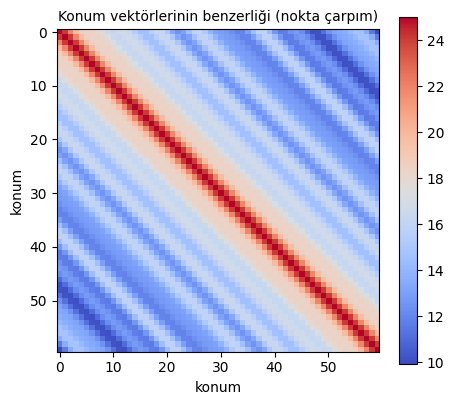

Aynı mesafe (3 adım), farklı yerler:
  PE(   5) · PE(   8) = 19.7657
  PE(  50) · PE(  53) = 19.7657
  PE( 500) · PE( 503) = 19.7657
  PE(1500) · PE(1503) = 19.7657
Farklı mesafe:
  PE(100) · PE( 101) = 24.0935   (mesafe 1)
  PE(100) · PE( 103) = 19.7657   (mesafe 3)
  PE(100) · PE( 110) = 16.3031   (mesafe 10)
  PE(100) · PE( 130) = 12.9014   (mesafe 30)


In [11]:
sim = PE[:60] @ PE[:60].T
fig, ax = plt.subplots(figsize=(5.2, 4.5))
im = ax.imshow(sim, cmap="coolwarm")
ax.set_xlabel("konum"); ax.set_ylabel("konum")
ax.set_title("Konum vektörlerinin benzerliği (nokta çarpım)", fontsize=10)
plt.colorbar(im, ax=ax)
plt.savefig("pe_similarity.png", dpi=130, bbox_inches="tight")
plt.show()

print("Aynı mesafe (3 adım), farklı yerler:")
for p in [5, 50, 500, 1500]:
    print(f"  PE({p:>4}) · PE({p+3:>4}) = {PE[p] @ PE[p+3]:.4f}")
print("Farklı mesafe:")
for k in [1, 3, 10, 30]:
    print(f"  PE(100) · PE({100+k:>4}) = {PE[100] @ PE[100+k]:.4f}   (mesafe {k})")

**Ne gördük?**

- Tabloda **köşegene paralel şeritler** var. Bir şerit boyunca (yani aynı mesafe boyunca) renk hiç değişmiyor.
- Sayılar da bunu doğruluyor: 5-8, 50-53, 500-503, 1500-1503 çiftlerinin hepsinde benzerlik **aynı**. Benzerlik "neredesin"e değil, sadece "**aranızda kaç adım var**"a bağlı.
- Mesafe arttıkça benzerlik düşüyor: mesafe 0'da 25 (vektörün kendisiyle), 1'de 24.1, 3'te 19.8, 10'da 16.3, 30'da 12.9. Uzun mesafelerde bu düşüş düzgün değil, dalgalı (Egzersiz 4).

**Dürüst not:** Nokta çarpım **yönü** göremiyor: "3 adım ileri" ile "3 adım geri" aynı sayıyı veriyor. Ayrıca bu güzel özellik sadece konum vektörlerinin **kendi arasında** geçerli. Embedding'le toplandıktan ve `W_Q`, `W_K` ile çarpıldıktan sonra kelime ve konum bilgisi karışıyor. Modern RoPE tam bu noktayı düzeltiyor (Bölüm 7).

### 5.4) "k adım sonrası" = ibreleri sabit bir açı kadar çevirmek (isteğe bağlı)

Saatte 10 dakika ileri gitmek istiyorsan, şu an saatin kaç olduğu önemli değil: dakika ibresini hep **aynı açıyla** çevirirsin. Konum vektörlerinde de aynısı geçerli: PE(pos)'tan PE(pos + k)'ya geçmek için her ibreyi `k · ω_i` kadar döndüren **tek bir matris** yeterli, ve bu matris `pos`'a bağlı değil. Makalenin "model göreceli konumları kolayca öğrenebilir" iddiasının arkasındaki fikir bu.

In [12]:
def shift_matrix(k, d, base=10000):
    """PE(pos)'u PE(pos+k)'ya çeviren matris: her ibreyi k*omega kadar döndürür. pos'a bağlı değil!"""
    M = np.zeros((d, d))
    for i, w in enumerate(omegas(d, base)):
        c, s = np.cos(k * w), np.sin(k * w)
        M[2*i:2*i+2, 2*i:2*i+2] = [[c, s], [-s, c]]      # 2x2 döndürme (sin, cos) çifti için
    return M

M7 = shift_matrix(7, d_model)
for p in [0, 12, 300, 1900]:
    print(f"M_7 @ PE({p:>4}) == PE({p+7:>4}) ?  {np.allclose(PE[p] @ M7.T, PE[p + 7])}")

M_7 @ PE(   0) == PE(   7) ?  True
M_7 @ PE(  12) == PE(  19) ?  True
M_7 @ PE( 300) == PE( 307) ?  True
M_7 @ PE(1900) == PE(1907) ?  True


**Ne gördük?** Aynı `M_7` matrisi 0, 12, 300 ve 1900'ün hepsini 7 adım ileri taşıyor. "7 adım sonra" her yerde aynı işlem.

## 6) İşe yaradı mı?

### 6.1) Oyuncak örnek

Bölüm 1'deki deneyi tekrarlıyoruz. Tek fark: kelimeleri attention'a sokmadan önce konum vektörlerini ekliyoruz.

In [13]:
PE_8 = positional_encoding(3, 8)          # oyuncak örnekte vektörler 8 sayılıktı
o1_pe, o2_pe = run_toy(sira_1, PE_8), run_toy(sira_2, PE_8)
print(f"Sıra 1: {' '.join(sira_1)}      Sıra 2: {' '.join(sira_2)}\n")
print(f"{'kelime':>7} | {'PE yok: aynı mı?':>17} | {'PE var: aynı mı?':>17} | {'PE var: benzerlik':>18}")
for w in words_toy:
    print(f"{w:>7} | {str(np.allclose(o1[w], o2[w])):>17} | {str(np.allclose(o1_pe[w], o2_pe[w])):>17} | {cosine(o1_pe[w], o2_pe[w]):>18.4f}")

Sıra 1: kara kutu düştü      Sıra 2: düştü kara kutu

 kelime |  PE yok: aynı mı? |  PE var: aynı mı? |  PE var: benzerlik
   kara |              True |             False |             0.9733
   kutu |              True |             False |             0.9952
  düştü |              True |             False |             0.8522


**Ne gördük?** Konum eklenince aynı kelime, farklı sırada **farklı bir çıktı** alıyor. Attention artık sırayı görüyor.

### 6.2) Gerçek veri: "büyük ev" ve "ev büyük"

Şimdi gerçek Türkçe embedding'lerle, 04'teki 5 kafalı multi-head attention'la deneyelim. Ağırlıklar 04'teki gibi **rastgele** (tohum 7).

In [14]:
n_heads = 5
rng_real = np.random.default_rng(7)
W_Q_r, W_K_r, W_V_r, W_O_r = (rng_real.normal(size=(d_model, d_model)) / np.sqrt(d_model) for _ in range(4))

def mha_sentence(tokens, use_pe):
    """Cümleyi embedding'e çevir, istenirse konum ekle, 5 kafalı attention'dan geçir."""
    X = np.stack([E_tr[word2id_tr[t]] for t in tokens])
    if use_pe:
        X = X + PE[:len(tokens)]
    out, _ = multi_head_attention(X, W_Q_r, W_K_r, W_V_r, W_O_r, n_heads)
    return dict(zip(tokens, out))

ifade_1, ifade_2 = ["büyük", "ev"], ["ev", "büyük"]
print(f"'{' '.join(ifade_1)}' ile '{' '.join(ifade_2)}' karşılaştırması:\n")
print(f"{'kelime':>7} | {'PE yok: benzerlik':>18} | {'PE var: benzerlik':>18}")
for w in ["büyük", "ev"]:
    a0, b0 = mha_sentence(ifade_1, False)[w], mha_sentence(ifade_2, False)[w]
    a1, b1 = mha_sentence(ifade_1, True)[w], mha_sentence(ifade_2, True)[w]
    print(f"{w:>7} | {cosine(a0, b0):>18.4f} | {cosine(a1, b1):>18.4f}")

'büyük ev' ile 'ev büyük' karşılaştırması:

 kelime |  PE yok: benzerlik |  PE var: benzerlik
  büyük |             1.0000 |             0.9932
     ev |             1.0000 |             0.9966


04'ün Egzersiz 6'sındaki permütasyon testini de tekrar edelim: cümleyi karıştır → attention → geri sırala → orijinalle aynı mı?

In [15]:
sentence_A = ["kara", "kuvvetleri", "sınırı", "geçti"]
X_A = np.stack([E_tr[word2id_tr[t]] for t in sentence_A])
perm = np.random.default_rng(3).permutation(len(sentence_A))
inv = np.argsort(perm)
print("Karıştırılmış sıra:", " ".join(sentence_A[i] for i in perm), "\n")

for use_pe in [False, True]:
    X_orig = X_A + (PE[:4] if use_pe else 0)
    X_shuf = X_A[perm] + (PE[:4] if use_pe else 0)      # dikkat: konumlar karıştırmadan SONRA ekleniyor
    out_orig, _ = multi_head_attention(X_orig, W_Q_r, W_K_r, W_V_r, W_O_r, n_heads)
    out_shuf, _ = multi_head_attention(X_shuf, W_Q_r, W_K_r, W_V_r, W_O_r, n_heads)
    ayni = np.allclose(out_shuf[inv], out_orig)
    print(f"PE {'var' if use_pe else 'yok'}: karıştır -> attention -> geri sırala == orijinal?  {ayni}")

Karıştırılmış sıra: geçti sınırı kuvvetleri kara 

PE yok: karıştır -> attention -> geri sırala == orijinal?  True
PE var: karıştır -> attention -> geri sırala == orijinal?  False


**Ne gördük?**

- PE yokken `"ev"`, `"büyük ev"` ve `"ev büyük"` içinde **tamamen aynı** çıktıyı alıyor (benzerlik tam 1.0). PE ekleyince benzerlik 1'in altına iniyor (~0.99). Fark **küçük**, ama artık sıfır değil: model iki ifadeyi ayırt **edebilir**. Küçük olmasının sebebi 04'teki ile aynı: rastgele, küçük ölçekli ağırlıklarla softmax neredeyse düz çıkıyor. Eğitim, işe yarıyorsa bu farkı büyütmeyi öğrenir.
- Permütasyon testi: PE yokken karıştırmak hiçbir şeyi değiştirmiyordu (`True`). PE varken artık değiştiriyor (`False`). **Sıraya körlük kalktı.**
- Konum vektörünü karıştırmadan **sonra** eklediğimize dikkat et: kelimeler yer değiştiriyor ama "1. sıra", "2. sıra" kartları yerinde kalıyor. Gerçek bir modelde de böyle: konum, kelimenin cümledeki yerinden geliyor.

**Dürüst okuma (03-04'teki uyarının aynısı):** Ağırlıklar rastgele. PE, modelin sırayı **görebilmesini** sağlıyor. Sırayı **anlamlı kullanmayı** (örneğin "sıfat isimden önce gelir") eğitim öğretiyor. Burada gösterdiğimiz şey yine **kapasite**.

## 7) Modern alternatif: RoPE'a kısa bakış

Sinüzoidal PE'nin 2017'den beri birkaç rakibi çıktı:

- **Öğrenilen konum vektörleri** (BERT, GPT-2): Her konum için 50 sayıyı formülle değil, eğitimle öğren. Basit, ama eğitimde görülmeyen konumlar için vektör yok.
- **ALiBi** (Press ve ark., 2022): Girdiye hiçbir şey ekleme. Attention skorundan, iki kelime arasındaki mesafeyle orantılı bir ceza çıkar.
- **RoPE** (*Rotary Position Embedding*, Su ve ark., 2021): Bugün LLaMA ailesi gibi birçok açık modelin kullandığı yöntem.

### RoPE'un sezgisi

Bölüm 5.3'teki dürüst notu hatırla: sinüzoidal PE'nin "benzerlik sadece mesafeye bağlı" özelliği, embedding'le toplanıp `W_Q`, `W_K`'dan geçince bozuluyor. RoPE bu yüzden **hiçbir şey eklemiyor**. Onun yerine:

> Q ve K vektörlerini, kelimenin konumu kadar **döndür**. (Aynı saat ibresi fikri: 50 sayı = 25 ibre, her biri farklı hızda.)

Neden işe yarıyor? İki ibreyi ikisini de **aynı açıyla** çevirirsen, aralarındaki açı değişmez. `"kara"` 3. sırada ve `"kutu"` 5. sırada ise, ikisini 103. ve 105. sıraya taşımak ikisini de ekstra 100 adım çevirmek demek: aralarındaki açı aynı kalıyor. Yani attention skoru **sadece aralarındaki mesafeye** (2 adım) bağlı. Ve bu sefer bu özellik doğrudan **attention skorunda** geçerli.

In [16]:
def rope(x, pos, base=10000):
    """x vektörünün her (2i, 2i+1) sayı çiftini pos * omega_i kadar döndür (RoPE).
    x: (d,) tek vektör, pos: tek bir konum."""
    a = pos * omegas(len(x), base)
    x_even, x_odd = x[0::2], x[1::2]
    out = np.empty_like(x)
    out[0::2] = x_even * np.cos(a) - x_odd * np.sin(a)
    out[1::2] = x_even * np.sin(a) + x_odd * np.cos(a)
    return out

rng_rope = np.random.default_rng(0)
q, k = rng_rope.normal(size=10), rng_rope.normal(size=10)   # bir kafanın 10 sayılık query'si ve key'i

print("Aynı mesafe (2 adım), farklı yerler:")
for m in [3, 10, 100, 1000]:
    print(f"  skor( q @ konum {m:>4},  k @ konum {m+2:>4} ) = {rope(q, m) @ rope(k, m + 2):.4f}")
print("Farklı mesafe:")
for gap in [0, 1, 5, 20]:
    print(f"  skor( q @ konum   10,  k @ konum {10+gap:>4} ) = {rope(q, 10) @ rope(k, 10 + gap):.4f}   (mesafe {gap})")
print(f"\nDöndürme vektörün uzunluğunu değiştiriyor mu? |q| = {np.linalg.norm(q):.4f}, |rope(q, 500)| = {np.linalg.norm(rope(q, 500)):.4f}")

Aynı mesafe (2 adım), farklı yerler:
  skor( q @ konum    3,  k @ konum    5 ) = -3.6229
  skor( q @ konum   10,  k @ konum   12 ) = -3.6229
  skor( q @ konum  100,  k @ konum  102 ) = -3.6229
  skor( q @ konum 1000,  k @ konum 1002 ) = -3.6229
Farklı mesafe:
  skor( q @ konum   10,  k @ konum   10 ) = -3.8113   (mesafe 0)
  skor( q @ konum   10,  k @ konum   11 ) = -3.7269   (mesafe 1)
  skor( q @ konum   10,  k @ konum   15 ) = -3.5587   (mesafe 5)
  skor( q @ konum   10,  k @ konum   30 ) = -1.1228   (mesafe 20)

Döndürme vektörün uzunluğunu değiştiriyor mu? |q| = 2.3592, |rope(q, 500)| = 2.3592


**Ne gördük?**

- Aynı mesafede skor **birebir aynı**, konum 3'te de 1000'de de. Farklı mesafede skor değişiyor. Model "kaç adım uzaktayız"ı doğrudan skorda görüyor.
- Döndürme vektörün uzunluğunu değiştirmiyor: kelime bilgisi (vektörün büyüklüğü ve ibreler arası ilişkiler) korunuyor, sadece yön konuma göre çevriliyor. Fikir A'daki "boğma" sorunu burada hiç yok.

Egzersiz 6'da RoPE ile sinüzoidal toplamayı gerçek veride yan yana koyacaksın.

### Tez bağlantısı: uzun bağlam

SAYZEK aday konularından **#10 (uzun bağlam vs RAG)** doğrudan bu notebook'a dayanıyor. Bir model eğitimde en fazla, örneğin, 4096 konum gördüyse, 10.000. konumdaki "saat görüntüsü" ona yabancıdır. Press ve ark. (2022), sinüzoidal PE'li modellerin eğitimde gördüklerinden uzun metinlerde başarısının hızla düştüğünü gösterdi. RoPE kullanan modellerin bağlamını uzatmak için de **Position Interpolation** (Chen ve ark., 2023) gibi yöntemler geliştirildi. Saat benzetmesiyle fikir şu: yeni konumlara taşmak yerine, uzun metni ibrelerin eğitimde gördüğü aralığa **sıkıştırmak** (ibreleri yavaşlatmak). "Bağlamı uzatmak mı, yoksa RAG ile sadece ilgili parçayı getirmek mi?" sorusunun teknik kökü burada.

## 8) Özet

- **Attention sıraya kör.** Her adımı ya tek kelimeye ya kelime çiftlerine uygulanıyor. Hiçbir adım "kaçıncı sıradasın?" diye sormuyor. `"büyük ev"` = `"ev büyük"`.
- **Çözüm: girdiye konum bilgisi ekle.** girdi = embedding (ne?) + konum vektörü (nerede?). Attention'ın kendisi değişmiyor.
- **Naif fikirler bozuluyor.** Sıra numarasını eklemek kelimeyi boğuyor. 0-1'e sıkıştırmak cümle uzunluğuna bağımlı yapıyor.
- **Sinüzoidal PE = farklı hızlarda dönen 25 saat ibresi.** Sayılar hep -1..1, her konumun uzunluğu aynı (5), 2000 konumun hiçbiri çakışmıyor, iki konumun benzerliği sadece aradaki mesafeye bağlı, "k adım ileri" her yerde aynı döndürme.
- **İşe yarıyor:** PE ile permütasyon testi artık `False`. Ağırlıklar rastgele olduğu için bu yine anlam değil, **kapasite**.
- **RoPE:** Toplamak yerine Q ve K'yı konum kadar döndür. Attention skoru doğrudan göreceli mesafeye bağlı oluyor. Uzun bağlam tartışmasının (tez konusu #10) temeli.

## Egzersizler

Çözümler verilmiyor. Her egzersizin altında boş bir kod hücresi var. Her çözümde kendi üretecini (`np.random.default_rng(...)`) o hücrenin içinde oluştur.

**Değişken adı uyarısı:** `PE`, `d_model`, `n_heads`, `E_tr`, `W_Q_r`... global. Egzersizlerde bunları ezme (`PE_ex`, `d_ex` gibi farklı isimler kullan). 04'teki `h`/`d` sorununun aynısı.

### Egzersiz 1 — 10000 sayısı nereden geliyor?

`positional_encoding` fonksiyonunun `base` parametresi 10000. Bunu **10**, **10000** ve **1.000.000** için dene.

(a) Her base için en yavaş ibrenin bir tam turu kaç adım sürüyor? (`2π / omegas(50, base).min()`)

(b) Her base için ilk 2000 konumda **en yakın iki farklı konum arasındaki mesafeyi** bul (Bölüm 5.2'deki kod). Hangi base'de konumlar birbirine en çok yaklaşıyor?

(c) Üç base için Bölüm 5.3'teki benzerlik tablosunu (ilk 60 konum) yan yana çiz. Ne değişiyor?

(d) Kendi cümlelerinle: base çok küçük olursa ne sorun çıkar? Çok büyük olursa?


==== Egzersiz 1: Base Sayısı Neden 10000? ====
     base |  en yavaş ibre turu |  komşu mesafesi |  tüm çiftlerde min |  >=10 adım uzakta min
       10 |            57 adım |          2.3708 |             2.3708 |                5.2630
      100 |           523 adım |          1.7575 |             1.7575 |                5.6654
     1000 |         4,766 adım |          1.4947 |             1.4947 |                4.7192
    10000 |        43,469 adım |          1.3465 |             1.3465 |                4.0398
   100000 |       396,442 adım |          1.2511 |             1.2511 |                3.5291
  1000000 |     3,615,596 adım |          1.1850 |             1.1850 |                3.1094


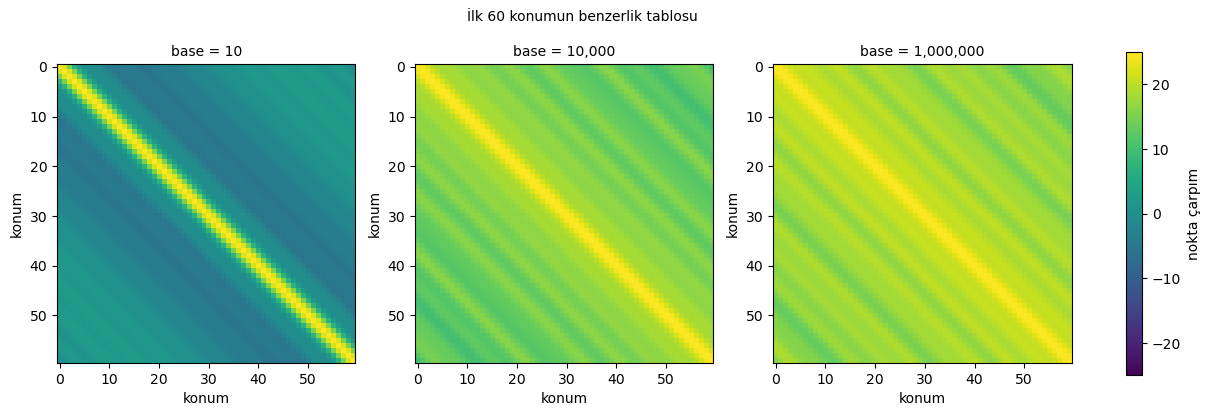

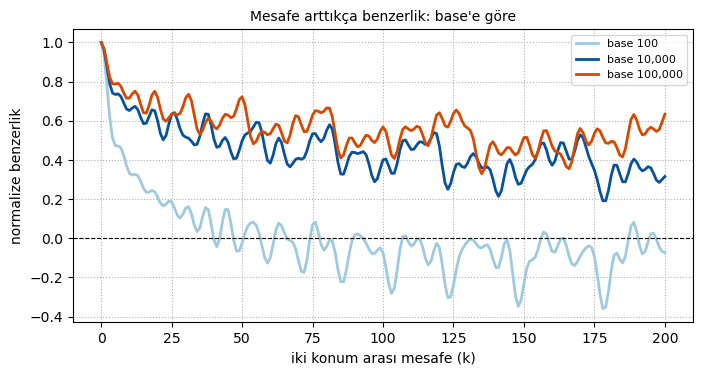


   base |     k=1    k=10    k=30    k=60   k=120
    100 |   0.938   0.332   0.154  -0.100  -0.048
  10000 |   0.964   0.652   0.516   0.383   0.471
 100000 |   0.969   0.716   0.717   0.533   0.641


In [32]:
print("\n==== Egzersiz 1: Base Sayısı Neden 10000? ====")
base_list = [10, 100, 1000, 10000, 100000, 1000000]

positions_ex1 = np.arange(2000)
gap_ex1 = np.abs(positions_ex1[:, None] - positions_ex1[None, :])     # iki konum arası kaç adım
PE_by_base = {}                                                        # (c) ve profil grafiği için sakla

# (a) + (b): tur süresi ve mesafeler
print(f"{'base':>9} | {'en yavaş ibre turu':>19} | {'komşu mesafesi':>15} | {'tüm çiftlerde min':>18} | {'>=10 adım uzakta min':>21}")
for base in base_list:
    PE_ex1 = positional_encoding(2000, d_model, base)
    PE_by_base[base] = PE_ex1
    tur_ex1 = 2 * np.pi / omegas(d_model, base).min()                   # adım cinsinden (50 sayı = boyut, cümle değil)

    sq_ex1 = (PE_ex1 ** 2).sum(axis=1)
    dist_ex1 = np.sqrt(np.maximum(sq_ex1[:, None] + sq_ex1[None, :] - 2 * PE_ex1 @ PE_ex1.T, 0))   # 2000 x 2000
    np.fill_diagonal(dist_ex1, np.inf)                                  # kendisiyle mesafeyi sayma
    komsu_ex1 = np.linalg.norm(PE_ex1[0] - PE_ex1[1])
    uzak_ex1 = dist_ex1[gap_ex1 >= 10].min()
    print(f"{base:>9} | {tur_ex1:>13,.0f} adım | {komsu_ex1:>15.4f} | {dist_ex1.min():>18.4f} | {uzak_ex1:>21.4f}")

# (c) benzerlik tabloları yan yana: küçük, makaledeki, büyük base
secilen_ex1 = [10, 10000, 1000000]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, base in zip(axes, secilen_ex1):
    P_ = PE_by_base[base][:60]
    im = ax.imshow(P_ @ P_.T, cmap="viridis", vmin=-25, vmax=25)
    ax.set_title(f"base = {base:,}", fontsize=10); ax.set_xlabel("konum"); ax.set_ylabel("konum")
plt.colorbar(im, ax=axes, fraction=0.015, label="nokta çarpım")
plt.suptitle("İlk 60 konumun benzerlik tablosu", fontsize=10)
plt.show()

# Benzerlik profili: PE[0] · PE[k], 25'e bölerek normalize (1 = aynı konum)
k_ex1 = np.arange(201)
fig, ax = plt.subplots(figsize=(8, 3.8))
for base, color in [(100, "#9ecae1"), (10000, "#08519c"), (100000, "#d94801")]:
    prof_ex1 = PE_by_base[base][0] @ PE_by_base[base][k_ex1].T / (d_model / 2)
    ax.plot(k_ex1, prof_ex1, color=color, lw=2, label=f"base {base:,}")
ax.axhline(0, color="black", ls="--", lw=0.8)
ax.set_xlabel("iki konum arası mesafe (k)"); ax.set_ylabel("normalize benzerlik")
ax.set_title("Mesafe arttıkça benzerlik: base'e göre", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, ls=":")
plt.savefig("base_profile.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"\n{'base':>7} | " + " ".join(f"{'k='+str(k):>7}" for k in [1, 10, 30, 60, 120]))
for base in [100, 10000, 100000]:
    P_ = PE_by_base[base]
    print(f"{base:>7} | " + " ".join(f"{P_[0] @ P_[k] / 25:>7.3f}" for k in [1, 10, 30, 60, 120]))

### Açıklama 1:

**(a) En yavaş ibrenin turu:** base 10'da sadece 57 adım, 10000'de ~43.500 adım, 1.000.000'da ~3,6 milyon adım. Base büyüdükçe en yavaş ibre çok daha geç başa dönüyor.

**(b) Mesafeler:**

* Hiçbir base'de iki konum çakışmıyor. Tüm çiftlerde en küçük mesafe her zaman **komşu** iki konumun mesafesi.
* **Base küçüldükçe komşular birbirinden uzaklaşıyor** (base 10: 2.37, 10000: 1.35, 1.000.000: 1.19), çünkü ibrelerin çoğu hızlı dönüyor. Yan yana kelimeleri ayırt etmek kolaylaşıyor.
* **Base büyüdükçe uzak konumlar da birbirine yaklaşıyor** (en az 10 adım uzak çiftlerde en küçük mesafe 10000'de 4.04, 1.000.000'da 3.11), çünkü ibrelerin çoğu neredeyse duruyor.

**(c) Benzerlik tabloları ve profil:**

* **Küçük base (10, 100):** Benzerlik mesafeyle hızla düşüyor, sonra dalgalanıyor, hatta negatife iniyor (base 100'de k=60'ta -0.10). 60 adım uzaktaki bir kelime, 120 adım uzaktakinden **daha az** benzer görünüyor. "Uzaklık" bilgisi karışıyor.
* **Base 10000:** Benzerlik dalgalanarak ama belirgin bir eğilimle düşüyor (k=1: 0.96, k=30: 0.52, k=60: 0.38) ve sıfırın üstünde kalıyor.
* **Büyük base (100000):** Benzerlik çok yavaş düşüyor: k=10 ve k=30'da ikisi de ~0.72. Model 10 adım ile 30 adım uzaklığı zor ayırt eder.

**(d) Takas:** Base çok küçükse ibreler çabuk başa döner; komşular iyi ayrılır ama uzak konumlar arasındaki ilişki karışık görünür. Base çok büyükse ibrelerin çoğu durur; uzun mesafeler iyi temsil edilir ama yakın ve orta mesafeler birbirine benzer. 10000, makalenin kullandığı cümle uzunlukları için ikisi arasında makul bir orta nokta (tasarım seçimi, kesin bir optimum değil).

### Egzersiz 2 — Sadece sinüs yeterli değil mi?

Her ibreyi iki sayıyla (sin, cos) yazıyoruz. Sadece sin'leri tutsak (25 sayı) ne olur?

(a) Sadece sinüs kullanan bir `pe_sin_only(n_pos, d)` yaz. Konum 0'ın vektörü ne çıkıyor? Bu neden sorun olabilir?

(b) Bölüm 5.4'teki "k adım sonrası = sabit bir matris" fikri burada hâlâ çalışır mı? (İpucu: sin 30° = sin 150°. Tek bir sinüs değerinden ibrenin nerede olduğunu kesin bilebilir misin?)

(c) Bir ibrenin durumunu tam olarak anlatmak için neden **iki** sayı gerekiyor?

In [33]:
print("\n==== Egzersiz 2: Sadece Sinüs Kullanan Positional Encoding ====")

def pe_sin_only(n_pos, d, base=10000):
    """Sadece sinüs: her ibreden TEK sayı (cos yok). Dönüş: (n_pos, d/2) = 2000 x 25."""
    pos = np.arange(n_pos)[:, None]                 # (n_pos, 1)
    angles = pos * omegas(d, base)[None, :]         # (n_pos, d/2): her konum x her ibre için açı
    return np.sin(angles)

PE_ex2 = pe_sin_only(2000, d_model)
print("PE_ex2 şekli:", PE_ex2.shape, "  <- 2000 konum x 25 sayı (her ibreden sadece sin)")

# (a) Konum 0
print(f"\n(a) Konum 0'ın vektörü: {np.round(PE_ex2[0], 2)}")
print(f"    Konum 0'ın uzunluğu: {np.linalg.norm(PE_ex2[0]):.3f}   |  sin+cos'ta her konum: {np.linalg.norm(PE[0]):.3f}")
uzunluklar_ex2 = np.linalg.norm(PE_ex2, axis=1)
print(f"    Sadece sin'de uzunluk konuma göre değişiyor: en küçük {uzunluklar_ex2.min():.3f}, en büyük {uzunluklar_ex2.max():.3f}")
sq_ex2 = (PE_ex2 ** 2).sum(axis=1)
dist_ex2 = np.sqrt(np.maximum(sq_ex2[:, None] + sq_ex2[None, :] - 2 * PE_ex2 @ PE_ex2.T, 0))
np.fill_diagonal(dist_ex2, np.inf)
print(f"    Konumlar hâlâ benzersiz mi? en küçük mesafe = {dist_ex2.min():.4f}  (0'dan büyük -> evet)")

# (b) "k adım sonrası = sabit matris" hâlâ çalışır mı?
# Bölüm 5.4'teki shift_matrix (sin, cos) çiftleri için kurulmuştu; burada çift yok.
# Daha güçlü soru: HERHANGİ bir lineer matris PE(pos) -> PE(pos+7) işini yapabilir mi?
# En iyi matrisi en küçük kareler (lstsq) ile verinin kendisinden bulalım ve hatasına bakalım.
k_ex2 = 7
S_ex2 = PE_ex2[:1500]
M_sin, _, _, _ = np.linalg.lstsq(S_ex2[:-k_ex2], S_ex2[k_ex2:], rcond=None)
hata_sin = np.abs(S_ex2[:-k_ex2] @ M_sin - S_ex2[k_ex2:]).max()

C_ex2 = PE[:1500]                                   # normal sin+cos PE
M_sc, _, _, _ = np.linalg.lstsq(C_ex2[:-k_ex2], C_ex2[k_ex2:], rcond=None)
hata_sc = np.abs(C_ex2[:-k_ex2] @ M_sc - C_ex2[k_ex2:]).max()

print(f"\n(b) PE(pos) -> PE(pos+7) için bulunabilen EN İYİ lineer matrisin en büyük hatası:")
print(f"    sadece sin : {hata_sin:.4f}   <- büyük: böyle bir matris yok")
print(f"    sin + cos  : {hata_sc:.2e}   <- ~0: matris var (Bölüm 5.4'teki M_7)")

# (c) Tek bir sin değeri ibrenin yerini söylemiyor
for aci in [30, 150]:
    r = np.radians(aci)
    print(f"\n(c) açı {aci:>3}°: sin = {np.sin(r):.3f}, cos = {np.cos(r):+.3f}", end="")
print()


==== Egzersiz 2: Sadece Sinüs Kullanan Positional Encoding ====
PE_ex2 şekli: (2000, 25)   <- 2000 konum x 25 sayı (her ibreden sadece sin)

(a) Konum 0'ın vektörü: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
    Konum 0'ın uzunluğu: 0.000   |  sin+cos'ta her konum: 5.000
    Sadece sin'de uzunluk konuma göre değişiyor: en küçük 0.000, en büyük 4.002
    Konumlar hâlâ benzersiz mi? en küçük mesafe = 0.2631  (0'dan büyük -> evet)

(b) PE(pos) -> PE(pos+7) için bulunabilen EN İYİ lineer matrisin en büyük hatası:
    sadece sin : 1.0739   <- büyük: böyle bir matris yok
    sin + cos  : 1.35e-13   <- ~0: matris var (Bölüm 5.4'teki M_7)

(c) açı  30°: sin = 0.500, cos = +0.866
(c) açı 150°: sin = 0.500, cos = -0.866


### Açıklama 2:

**(a) Konum 0 sıfır vektörü oluyor.** $\sin(0) = 0$ olduğu için ilk kelimeye eklenen konum vektörü tamamen sıfır, yani ilk kelimeye hiç konum sinyali eklenmiyor. Ama konum bilgisi tamamen kaybolmuyor: sıfır vektörü de diğerlerinden farklı bir desen, ve 2000 konum hâlâ birbirinden ayrılıyor (en küçük mesafe > 0). Asıl sorunlar başka yerde: vektörlerin uzunluğu konuma göre değişiyor (sin+cos'ta hepsi 5'ti), yani bazı konumlar kelimeye daha güçlü, bazıları daha zayıf sinyal ekliyor.

**(b) "k adım sonrası = sabit matris" bozuluyor.** Sadece Bölüm 5.4'teki matris değil, veriden bulunabilen **en iyi** lineer matris bile PE(pos)'u PE(pos+7)'ye çeviremiyor (hata ~1). sin+cos'ta ise hata ~0. Sebep: $\sin(\theta + \phi) = \sin\theta\cos\phi + \cos\theta\sin\phi$. Bir sonraki sinüsü hesaplamak için **şu anki kosinüse** ihtiyaç var. Kosinüs elimizde yoksa "7 adım ileri" konuma bağlı olmayan tek bir işlemle yapılamaz.

**(c) Neden iki sayı?** 30° ve 150°'nin sinüsü aynı (0.5), kosinüsleri farklı (+0.87 ve -0.87). Sadece sinüse bakarak ibrenin sağda mı solda mı olduğunu bilemezsin. Saat benzetmesiyle: yelkovanın sadece yüksekliğini biliyorsan saati söyleyemezsin, yatay konumunu da bilmen gerekir. (sin, cos) çifti ibrenin ucunun tam koordinatı.

### Egzersiz 3 — Toplama, kelimenin kimliğini bozuyor mu?

Toplamadan sonra "bu vektör hangi kelimeydi?" sorusuna cevap verebiliyor muyuz?

(a) Sözlükten 200 kelime seç (kendi üretecinle). Her kelime `w` ve konum `p` ∈ {0, 1, 5, 20, 100, 500} için `E_tr[w] + konum` vektörünü oluştur ve `E_tr`'deki **en yakın kelimeyi** (kosinüs benzerliğiyle) bul. En yakın kelime hâlâ `w` mi? Her `p` için doğru bulunan oranı yazdır.

(b) Bunu iki yöntem için yap: Fikir A (`+ p`) ve sinüzoidal (`+ PE[p]`).

(c) Sinüzoidal PE'yi 3 ile çarpıp (`+ 3 * PE[p]`) tekrarla. Sonuç sana konum sinyali ile kelime sinyalinin **ölçeği** hakkında ne söylüyor?

In [19]:
print("\n==== Egzersiz 3: Toplama, Kelimenin Kimliğini Bozuyor Mu? ====")

# Sözlükten 200 kelime seçelim, her birine konum ekleyelim, sonra en yakın kelimeyi arayalım (attention yok).
rng_ex3 = np.random.default_rng(42)
words_ex3 = rng_ex3.choice(id2word_tr, size=200, replace=False)
word_ids = np.array([word2id_tr[w] for w in words_ex3])

# Seçilen kelimelerin embedding'lerini alalım
emb_ex3 = E_tr[word_ids] 

# Normalizasyon: embedding'leri kosinüs benzerliği için normalize edelim
E_tr_norm = E_tr / (np.linalg.norm(E_tr, axis=1, keepdims=True) + 1e-9)

# Konumlar ve Yöntemler
konumlar = [0, 1, 5, 20, 100, 500]

# Test edilecek 3 farklı konum yöntemi
yontemler = {
    "Fikir A (+ p)": lambda p: np.ones(d_model) * p,
    "Sinüzoidal PE": lambda p: PE[p],
    "3 * Sinüzoidal PE": lambda p: 3 * PE[p]
}

# (a, b, c) Şıklarının Hepsini Hesaplayan Ana Döngü
for yontem_adi, konum_fonksiyonu in yontemler.items():
    print(f"\n--- Yöntem: {yontem_adi} ---")
    
    for p in konumlar:
        p_vec = konum_fonksiyonu(p) # İlgili konum vektörünü üret (Boyut: d_model,)
        
        # Kelime vektörlerine konumu ekle (Broadcasting ile 200 satıra birden eklenir)
        X_ex3 = emb_ex3 + p_vec # Boyut: 200 x d_model
        
        # Yeni oluşan vektörleri kosinüs benzerliği için normalize et
        X_ex3_norm = X_ex3 / (np.linalg.norm(X_ex3, axis=1, keepdims=True) + 1e-9)
        
        # Tüm sözlükle kosinüs benzerliğini hesapla (200 x Sözlük_Boyutu)
        # Nokta çarpım, matrisler normalize olduğu için doğrudan kosinüs benzerliğini verir
        benzerlik_matrisi = X_ex3_norm @ E_tr_norm.T 
        
        # En yakın kelimelerin indekslerini bul (Her satır için en büyük olan)
        en_yakin_indeksler = np.argmax(benzerlik_matrisi, axis=1)
        
        # En yakın bulunan kelime orijinal kelime (word_ids) ile aynı mı?
        dogru_tahminler = (en_yakin_indeksler == word_ids).sum()
        oran = dogru_tahminler / 200
        
        print(f"  Konum p = {p:3d} için kelime kimliğini koruma oranı: %{oran * 100:.1f}")

# (c) için: vektör uzunlukları karşılaştırması
print(f"\nUzunluklar: embedding ortalama {np.linalg.norm(emb_ex3, axis=1).mean():.2f} | PE {np.linalg.norm(PE[0]):.2f} | 3*PE {np.linalg.norm(3*PE[0]):.2f}")

print("\nYORUM (a, b): Fikir A'da konum 1'de bile oran %34.5'e, konum 5'ten sonra %0'a düşüyor: eklenen sayı büyüdükçe kelime kayboluyor.")
print("Sinüzoidal PE'de oran konumdan bağımsız olarak %75-90 arasında kalıyor, çünkü PE'nin uzunluğu her konumda 5 (büyümüyor).")
print("Oranın konuma göre düzgün değişmemesi (p=5: %78.5, p=20: %89.5) uzunluktan değil YÖNden: her konumun PE'si farklı yönde,")
print("bazı yönler kelimeleri başka kelimelere daha çok yaklaştırıyor. p=0'da bile %100 değil, çünkü PE[0] = [0,1,0,1,...]")
print("tüm kelimelerin tek sütunlarına +1 ekleyerek onları ortak bir yöne itiyor.")
print("\nYORUM (c): 3*PE ile oran %1-3'e düşüyor, yani kelime kimliği neredeyse tamamen kayboluyor. 3*PE'nin uzunluğu ~15,")
print("embedding'lerin ~4: konum sinyali kelime sinyalini ezmiş. Ders: önemli olan sadece PE'nin sınırlı olması değil,")
print("kelime sinyaline göre ÖLÇEĞİ. Makalede embedding'lerin sqrt(d) ile çarpılması bu dengeyi kelime lehine kuruyor.")


==== Egzersiz 3: Toplama, Kelimenin Kimliğini Bozuyor Mu? ====

--- Yöntem: Fikir A (+ p) ---
  Konum p =   0 için kelime kimliğini koruma oranı: %100.0
  Konum p =   1 için kelime kimliğini koruma oranı: %34.5
  Konum p =   5 için kelime kimliğini koruma oranı: %0.0
  Konum p =  20 için kelime kimliğini koruma oranı: %0.0
  Konum p = 100 için kelime kimliğini koruma oranı: %0.0
  Konum p = 500 için kelime kimliğini koruma oranı: %0.0

--- Yöntem: Sinüzoidal PE ---
  Konum p =   0 için kelime kimliğini koruma oranı: %83.0
  Konum p =   1 için kelime kimliğini koruma oranı: %80.0
  Konum p =   5 için kelime kimliğini koruma oranı: %78.5
  Konum p =  20 için kelime kimliğini koruma oranı: %89.5
  Konum p = 100 için kelime kimliğini koruma oranı: %88.5
  Konum p = 500 için kelime kimliğini koruma oranı: %75.0

--- Yöntem: 3 * Sinüzoidal PE ---
  Konum p =   0 için kelime kimliğini koruma oranı: %1.5
  Konum p =   1 için kelime kimliğini koruma oranı: %0.0
  Konum p =   5 için kelime kiml

### Egzersiz 4 — Mesafe profili

Bölüm 5.3'te benzerliğin mesafe arttıkça "dalgalanarak" düştüğünü söyledik.

(a) `PE[0] @ PE[k]`'yı k = 0, 1, ..., 300 için çiz.

(b) Eğri sürekli azalıyor mu? Uzak bir konumun, daha yakın bir konumdan **daha benzer** göründüğü bir k çifti bulabilir misin?

(c) Aynı grafiği d = 512 (makaledeki boyut) için çiz. Eğri nasıl değişiyor?


==== Egzersiz 4: Mesafe Profili ====


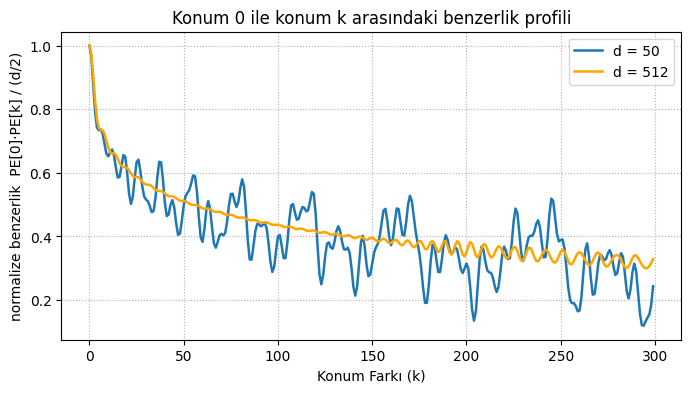

d = 50 : ilk artış k=6: benzerlik(k=6) = 0.73723 > benzerlik(k=5) = 0.73390 | en büyük tek adımlık artış = 0.0823 | en düşük değer 0.119 (k=294)
d = 512: ilk artış k=44: benzerlik(k=44) = 0.52645 > benzerlik(k=43) = 0.52640 | en büyük tek adımlık artış = 0.0203 | en düşük değer 0.300 (k=285)

YORUM (a, b): Eğri sürekli azalmıyor. d=50'de ilk artış k=6'da: 6 adım uzaktaki konum, 5 adım uzaktakinden daha benzer.
Sebep: en hızlı ibre ~6.3 adımda bir tur atıyor, 6. adımda başlangıç noktasına geri yaklaşıyor. Hızlı ibrelerin
tur atması benzerliğe dalgalar ekliyor.

YORUM (c): d=512'de eğri daha pürüzsüz: ilk artış çok daha geç (k=44) ve en büyük tek adımlık artış ~4 kat daha küçük.
Daha çok ibre olunca her birinin dalgası toplamda daha küçük bir pay alıyor ve dalgalar birbirini sönümlüyor.
d=512'de benzerlik genel olarak daha yüksek de kalıyor: yavaş ibre sayısı arttıkça uzak konumlar birbirine daha benzer.


In [20]:
print("\n==== Egzersiz 4: Mesafe Profili ====")

k_list = np.arange(300)

def mesafe_profili(d, n=400):
    """PE[0] · PE[k], k = 0..299. d/2'ye bölüyoruz ki farklı boyutları karşılaştırabilelim (1 = aynı konum)."""
    P_ = positional_encoding(n, d)
    return P_[0] @ P_[k_list].T / (d / 2)

def ilk_artis(prof):
    """Benzerliğin ilk kez arttığı k: k konumu, k-1 konumundan daha benzer."""
    k = int(np.argmax(np.diff(prof) > 0)) + 1
    return k, prof[k - 1], prof[k]

# (a) d = 50
prof_50 = mesafe_profili(d_model)
# (c) d = 512 (makaledeki boyut)
d_ex4 = 512
prof_512 = mesafe_profili(d_ex4)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_list, prof_50, lw=1.8, label="d = 50")
ax.plot(k_list, prof_512, lw=1.8, color="orange", label="d = 512")
ax.set_xlabel("Konum Farkı (k)")
ax.set_ylabel("normalize benzerlik  PE[0]·PE[k] / (d/2)")
ax.set_title("Konum 0 ile konum k arasındaki benzerlik profili")
ax.grid(True, ls=":"); ax.legend()
plt.show()

# (b) Uzak bir konum, daha yakın bir konumdan daha benzer olabiliyor mu?
for isim, prof in [("d = 50 ", prof_50), ("d = 512", prof_512)]:
    k, once, sonra = ilk_artis(prof)
    en_buyuk_artis = np.diff(prof).max()
    print(f"{isim}: ilk artış k={k}: benzerlik(k={k}) = {sonra:.5f} > benzerlik(k={k-1}) = {once:.5f}"
          f" | en büyük tek adımlık artış = {en_buyuk_artis:.4f} | en düşük değer {prof.min():.3f} (k={prof.argmin()})")

print("\nYORUM (a, b): Eğri sürekli azalmıyor. d=50'de ilk artış k=6'da: 6 adım uzaktaki konum, 5 adım uzaktakinden daha benzer.")
print("Sebep: en hızlı ibre ~6.3 adımda bir tur atıyor, 6. adımda başlangıç noktasına geri yaklaşıyor. Hızlı ibrelerin")
print("tur atması benzerliğe dalgalar ekliyor.")
print("\nYORUM (c): d=512'de eğri daha pürüzsüz: ilk artış çok daha geç (k=44) ve en büyük tek adımlık artış ~4 kat daha küçük.")
print("Daha çok ibre olunca her birinin dalgası toplamda daha küçük bir pay alıyor ve dalgalar birbirini sönümlüyor.")
print("d=512'de benzerlik genel olarak daha yüksek de kalıyor: yavaş ibre sayısı arttıkça uzak konumlar birbirine daha benzer.")

### Egzersiz 5 — Causal mask kendi başına sıra bilgisi verir mi?

04'ün Egzersiz 3'ünde causal mask'ı (her kelime sadece kendisine ve öncekilere bakar) gördün. GPT gibi modeller hep bu maskla çalışıyor.

(a) **PE eklemeden**, Bölüm 6.2'deki permütasyon testini causal mask ile yap (`mask=np.tril(np.ones((4, 4)))`). Karıştır → attention → geri sırala == orijinal mi?

(b) Sonuç Bölüm 1'dekinden neden farklı? Kendi cümlelerinle açıkla. (İpucu: 1. kelime kaç kelimeye bakabiliyor, 4. kelime kaç kelimeye?)

(c) Haviv ve ark. (2022), hiç positional encoding kullanmayan causal dil modellerinin de konum bilgisini öğrenebildiğini gösterdi (bkz. Kaynaklar). (a)'daki sonuç bunu nasıl açıklıyor?

In [21]:
print("\n==== Egzersiz 5: Causal Mask Kendi Başına Sıra Bilgisi Verir Mi? ====")

def mha_sentence_with_mask(tokens, use_pe, attention_mask=None):
    """Cümleyi embedding'e çevir, istenirse konum ekle, 5 kafalı attention'dan geçir. İstenirse mask uygula.
    Dönüş: {kelime: çıktı}. Sözlük kelimeye göre tutulduğu için geri sıralamaya gerek yok."""
    X = np.stack([E_tr[word2id_tr[t]] for t in tokens])
    if use_pe:
        X = X + PE[:len(tokens)]
    out, _ = multi_head_attention(X, W_Q_r, W_K_r, W_V_r, W_O_r, n_heads, mask=attention_mask)
    return dict(zip(tokens, out))

causal_mask_ex5 = np.tril(np.ones((4, 4)))
sentence_test = ["kraliçe", "güzel", "bir", "düşünce"]
perm_ex5 = np.random.default_rng(3).permutation(len(sentence_test))
shuffled_sentence = [sentence_test[i] for i in perm_ex5]
print("Orijinal   :", " ".join(sentence_test))
print("Karıştırılmış:", " ".join(shuffled_sentence), "\n")

# (a) PE YOK; mask yok vs causal mask
for mask_adi, m in [("mask yok   ", None), ("causal mask", causal_mask_ex5)]:
    out_orig = mha_sentence_with_mask(sentence_test, use_pe=False, attention_mask=m)
    out_shuf = mha_sentence_with_mask(shuffled_sentence, use_pe=False, attention_mask=m)
    # İki sözlüğü de AYNI kelime sırasıyla okuyoruz -> ekstra [inv] gerekmez (önceki sürümdeki hata buydu)
    orig_vectors = np.stack([out_orig[t] for t in sentence_test])
    shuf_vectors = np.stack([out_shuf[t] for t in sentence_test])
    print(f"PE yok, {mask_adi}: karıştır -> attention -> kelimeye göre eşle == orijinal?  {np.allclose(shuf_vectors, orig_vectors)}")

# (b) Causal mask'ta her kelime kaç kelimeye bakabiliyor?
print("\n(b) Causal mask'ta her konumdaki kelimenin bakabildiği kelime sayısı:", causal_mask_ex5.sum(axis=1).astype(int))
print("    Orijinalde 'kraliçe' sadece kendine bakıyor; karıştırılmış cümlede son sırada, 4 kelimeye bakıyor.")

print("\nYORUM (a, b): Mask yokken sonuç True: kelimeleri karıştırmak hiçbir kelimenin çıktısını değiştirmiyor (Bölüm 1).")
print("Causal mask ile False: bir kelimenin çıktısı artık karıştırmadan etkileniyor. Sebep: mask konuma bağlı.")
print("1. kelime sadece kendine, 4. kelime dört kelimeye bakabiliyor. Bir kelimenin 'kaç kelimeyi gördüğü' kendi başına")
print("bir konum bilgisi. Mask, PE olmadan da modele 'ne kadar geridesin' sinyali sızdırıyor.")
print("\nYORUM (c): Haviv ve ark. (2022) bunu gösteriyor: PE'siz causal modeller bu sinyali kullanarak konumu kendileri")
print("öğreniyor. Örneğin bir kelime gördüğü tüm kelimelerin ortalamasını alırsa, ortalama kaç kelime üzerinden alındığına")
print("göre farklı görünür (erken konumda az, geç konumda çok kelime). Bu, mask'sız (çift yönlü, BERT gibi) modellerde çalışmaz:")
print("orada her kelime herkesi görüyor, bu yüzden PE şart. Amacımız sıralamaya 'dayanıklı' olmak değil, sıraya DUYARLI olmak.")


==== Egzersiz 5: Causal Mask Kendi Başına Sıra Bilgisi Verir Mi? ====
Orijinal   : kraliçe güzel bir düşünce
Karıştırılmış: düşünce bir güzel kraliçe 

PE yok, mask yok   : karıştır -> attention -> kelimeye göre eşle == orijinal?  True
PE yok, causal mask: karıştır -> attention -> kelimeye göre eşle == orijinal?  False

(b) Causal mask'ta her konumdaki kelimenin bakabildiği kelime sayısı: [1 2 3 4]
    Orijinalde 'kraliçe' sadece kendine bakıyor; karıştırılmış cümlede son sırada, 4 kelimeye bakıyor.

YORUM (a, b): Mask yokken sonuç True: kelimeleri karıştırmak hiçbir kelimenin çıktısını değiştirmiyor (Bölüm 1).
Causal mask ile False: bir kelimenin çıktısı artık karıştırmadan etkileniyor. Sebep: mask konuma bağlı.
1. kelime sadece kendine, 4. kelime dört kelimeye bakabiliyor. Bir kelimenin 'kaç kelimeyi gördüğü' kendi başına
bir konum bilgisi. Mask, PE olmadan da modele 'ne kadar geridesin' sinyali sızdırıyor.

YORUM (c): Haviv ve ark. (2022) bunu gösteriyor: PE'siz causal modeller bu 

### Egzersiz 6 — RoPE vs sinüzoidal toplama, gerçek veride

Cümle A'yı (`X_A`, 4 kelime) ve tek bir kafa için 50x50'lik `W_Q`, `W_K` kullan (`np.random.default_rng(7)` ile üret).

(a) **Sinüzoidal toplama:** Cümleyi konum 0-3'e yerleştir (`X_A + PE[0:4]`) ve 4x4'lük skor tablosunu (`Q @ K.T`) hesapla. Sonra aynı cümleyi konum 10-13'e yerleştir (`X_A + PE[10:14]`). İki tablo aynı mı?

(b) **RoPE:** Q ve K'yı PE eklemeden hesapla (`X_A @ W_Q`), sonra her satırı kendi konumu kadar `rope` ile döndür. Konum 0-3 ve 10-13 için skor tablolarını karşılaştır.

(c) Sonuçlar neden farklı? Cümleyi metnin başına ya da ortasına koymak anlamını değiştirmemeli. Bu açıdan hangi yöntem daha "doğru" davranıyor?

In [22]:
print("\n==== Egzersiz 6: RoPE vs Sinüzoidal PE ====")

rng_ex6 = np.random.default_rng(7)
d_ex6 = 50

W_Q_ex6 = rng_ex6.normal(size=(d_ex6, d_ex6)) / np.sqrt(d_ex6)
W_K_ex6 = rng_ex6.normal(size=(d_ex6, d_ex6)) / np.sqrt(d_ex6)

X_A_ex6 = np.stack([E_tr[word2id_tr[t]] for t in sentence_A])

print("\n--- (a) Sinüzoidal Toplama Testi ---")

# Konum 0-3 arası yerleşim
X_A_pos_0_3 = X_A_ex6 + PE[0:4]
Q_sin_0 = X_A_pos_0_3 @ W_Q_ex6
K_sin_0 = X_A_pos_0_3 @ W_K_ex6
skor_sin_0 = Q_sin_0 @ K_sin_0.T

# Konum 10-13 arası yerleşim
X_A_pos_10_13 = X_A_ex6 + PE[10:14]
Q_sin_10 = X_A_pos_10_13 @ W_Q_ex6
K_sin_10 = X_A_pos_10_13 @ W_K_ex6
skor_sin_10 = Q_sin_10 @ K_sin_10.T

ayni_sin = np.allclose(skor_sin_0, skor_sin_10)
print(f"Sinüzoidal PE (Konum 0-3) == (Konum 10-13) mi? {ayni_sin}")

print("\n--- (b) RoPE (Rotary Position Embedding) Testi ---")

# Adım 1: Önce PE eklemeden ham Q ve K projeksiyonlarını hesapla
Q_raw = X_A_ex6 @ W_Q_ex6
K_raw = X_A_ex6 @ W_K_ex6

# Adım 2: Konum 0-3 için RoPE rotasyonunu uygula
Q_rope_0 = np.stack([rope(Q_raw[i], 0 + i) for i in range(4)])
K_rope_0 = np.stack([rope(K_raw[i], 0 + i) for i in range(4)])
skor_rope_0 = Q_rope_0 @ K_rope_0.T

# Adım 3: Konum 10-13 için RoPE rotasyonunu uygula
Q_rope_10 = np.stack([rope(Q_raw[i], 10 + i) for i in range(4)])
K_rope_10 = np.stack([rope(K_raw[i], 10 + i) for i in range(4)])
skor_rope_10 = Q_rope_10 @ K_rope_10.T

ayni_rope = np.allclose(skor_rope_0, skor_rope_10)
print(f"RoPE (Konum 0-3) == (Konum 10-13) mi? {ayni_rope}")

# Ne kadar farklı? (a)'daki iki tablo arasındaki en büyük fark
print(f"\nSinüzoidal: iki tablo arasındaki en büyük fark = {np.abs(skor_sin_0 - skor_sin_10).max():.4f}")
print(f"RoPE      : iki tablo arasındaki en büyük fark = {np.abs(skor_rope_0 - skor_rope_10).max():.2e}")

print("\nYORUM (a): Sinüzoidal toplamada aynı cümleyi konum 0-3'ten 10-13'e kaydırınca skor tablosu DEĞİŞİYOR (False).")
print("PE kelimeye eklendiği için W_Q ve W_K'dan geçince kelime ve konum bilgisi karışıyor; skor mutlak konuma bağlı hale geliyor.")
print("\nYORUM (b): RoPE'da skor tablosu AYNI kalıyor (True). İki vektörü aynı ekstra açıyla (10 adım) döndürmek aralarındaki")
print("açıyı değiştirmiyor, bu yüzden skor sadece iki kelime arasındaki MESAFEYE bağlı.")
print("\nYORUM (c): Bir cümleyi metnin başına ya da ortasına koymak anlamını değiştirmemeli. Bu açıdan RoPE daha doğru")
print("davranıyor: attention skoru mutlak konuma değil, göreceli mesafeye bakıyor. Modern LLM'lerin RoPE'u tercih")
print("etmesinin sebeplerinden biri bu.")


==== Egzersiz 6: RoPE vs Sinüzoidal PE ====

--- (a) Sinüzoidal Toplama Testi ---
Sinüzoidal PE (Konum 0-3) == (Konum 10-13) mi? False

--- (b) RoPE (Rotary Position Embedding) Testi ---
RoPE (Konum 0-3) == (Konum 10-13) mi? True

Sinüzoidal: iki tablo arasındaki en büyük fark = 8.3554
RoPE      : iki tablo arasındaki en büyük fark = 7.11e-15

YORUM (a): Sinüzoidal toplamada aynı cümleyi konum 0-3'ten 10-13'e kaydırınca skor tablosu DEĞİŞİYOR (False).
PE kelimeye eklendiği için W_Q ve W_K'dan geçince kelime ve konum bilgisi karışıyor; skor mutlak konuma bağlı hale geliyor.

YORUM (b): RoPE'da skor tablosu AYNI kalıyor (True). İki vektörü aynı ekstra açıyla (10 adım) döndürmek aralarındaki
açıyı değiştirmiyor, bu yüzden skor sadece iki kelime arasındaki MESAFEYE bağlı.

YORUM (c): Bir cümleyi metnin başına ya da ortasına koymak anlamını değiştirmemeli. Bu açıdan RoPE daha doğru
davranıyor: attention skoru mutlak konuma değil, göreceli mesafeye bakıyor. Modern LLM'lerin RoPE'u tercih
et

## Kaynaklar

- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) — sinüzoidal positional encoding'in orijinal tanımı (Bölüm 3.5).
- Kazemnejad, A. (2019). *Transformer Architecture: The Positional Encoding.* [kazemnejad.com/blog/transformer_architecture_positional_encoding](https://kazemnejad.com/blog/transformer_architecture_positional_encoding/) — **bu notebook'la birlikte okumak için en uygun kaynak.** İkili sayaç benzetmesi ve "k adım sonrası = döndürme" fikrinin sade anlatımı.
- Alammar, J. *The Illustrated Transformer.* [jalammar.github.io/illustrated-transformer](https://jalammar.github.io/illustrated-transformer/) — "Representing The Order of The Sequence Using Positional Encoding" bölümü.
- Su, J., Lu, Y., Pan, S., Murtadha, A., Wen, B., Liu, Y. (2021). *RoFormer: Enhanced Transformer with Rotary Position Embedding.* [arXiv:2104.09864](https://arxiv.org/abs/2104.09864) — RoPE'un orijinal makalesi.
- Biderman, S., Black, S., et al. (2021). *Rotary Embeddings: A Relative Revolution.* EleutherAI Blog. [blog.eleuther.ai/rotary-embeddings](https://blog.eleuther.ai/rotary-embeddings/) — RoPE'un sezgisel anlatımı ve deneyler.
- Press, O., Smith, N. A., Lewis, M. (2022). *Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation.* ICLR 2022. [arXiv:2108.12409](https://arxiv.org/abs/2108.12409) — ALiBi; sinüzoidal PE'nin uzun metinlere genelleme sorunu.
- Haviv, A., Ram, O., Press, O., Izsak, P., Levy, O. (2022). *Transformer Language Models without Positional Encodings Still Learn Positional Information.* Findings of EMNLP 2022. [arXiv:2203.16634](https://arxiv.org/abs/2203.16634) — causal mask'ın kendi başına konum bilgisi taşıması (Egzersiz 5).
- Chen, S., Wong, S., Chen, L., Tian, Y. (2023). *Extending Context Window of Large Language Models via Positional Interpolation.* [arXiv:2306.15595](https://arxiv.org/abs/2306.15595) — RoPE'lu modellerde bağlam uzatma (tez konusu #10 için ileri okuma).
- Veri: *Turkish-Wiki-NER-Dataset*, [turkish-nlp-suite/Turkish-Wiki-NER-Dataset](https://github.com/turkish-nlp-suite/Turkish-Wiki-NER-Dataset) (CC-BY-SA-4.0).